---

# Bochner Verification for Triangular Autocorrelation

Given
$$
x(t)=\beta\,\xi(t)\cos(\omega_0 t+\Phi),
$$
where $\beta,\omega_0\in\mathbb{R}$, $\Phi\sim\mathcal U[-\pi,\pi]$, and $\Phi$ is independent of $\xi(t)$.
Also, $\xi(t)$ is WSS with
$$
\mathbb E[\xi(t)]=0,
\quad
R_\xi(\tau)=
\begin{cases}
\sigma_\xi^2\left(1-\dfrac{|\tau|}{T}\right), & |\tau|\le T,\\[4pt]
0, & |\tau|>T.
\end{cases}
$$

## 1) Bochner check for $R_\xi(\tau)$

By Bochner (WSS version), $R_\xi(\tau)$ is a valid autocorrelation iff its Fourier transform (PSD) is nonnegative:
$$
S_\xi(\omega)=\int_{-\infty}^{\infty}R_\xi(\tau)e^{-j\omega\tau}d\tau\ge0.
$$

Compute:
$$
S_\xi(\omega)=\sigma_\xi^2\int_{-T}^{T}\left(1-\frac{|\tau|}{T}\right)e^{-j\omega\tau}d\tau
=2\sigma_\xi^2\int_0^{T}\left(1-\frac{\tau}{T}\right)\cos(\omega\tau)d\tau.
$$
This yields
$$
S_\xi(\omega)=\sigma_\xi^2 T\left(\frac{\sin(\omega T/2)}{\omega T/2}\right)^2
=\sigma_\xi^2 T\,\mathrm{sinc}^2\!\left(\frac{\omega T}{2}\right),
$$
(with $\mathrm{sinc}(u)=\sin(u)/u$, and the continuous value at $\omega=0$: $S_\xi(0)=\sigma_\xi^2T$).

Since $\mathrm{sinc}^2(\cdot)\ge0$,
$$
S_\xi(\omega)\ge0\quad\forall\omega,
$$
so $R_\xi(\tau)$ is a valid autocorrelation function.

## 2) Conditions implied for $\xi(t)$

For this to define a WSS second-order process, the required parameter conditions are:

1. $T>0$ (correlation width must be positive).
2. $\sigma_\xi^2\ge0$ (variance-like scale, with $R_\xi(0)=\sigma_\xi^2$).
3. Finite power: $R_\xi(0)<\infty$, hence $\sigma_\xi^2<\infty$.

Properties of $\xi(t)$ implied by this $R_\xi$:

- Variance: $\mathrm{Var}[\xi(t)]=\sigma_\xi^2$.
- Finite correlation span: $R_\xi(\tau)=0$ for $|\tau|>T$ (uncorrelated beyond lag $T$).
- Mean-square continuity: yes, because $R_\xi(\tau)$ is continuous at $\tau=0$.
- Mean-square differentiability: no in general, because $R_\xi(\tau)$ has a cusp at $\tau=0$.

## 3) Consequence for $x(t)=\beta\xi(t)\cos(\omega_0 t+\Phi)$

Using independence of $\Phi$ and $\xi$, and $\Phi\sim\mathcal U[-\pi,\pi]$:
$$
\mathbb E[x(t)]=\beta\,\mathbb E[\xi(t)]\,\mathbb E[\cos(\omega_0 t+\Phi)]=0.
$$
Also,
$$
R_x(\tau)=\frac{\beta^2}{2}R_\xi(\tau)\cos(\omega_0\tau),
$$
so $x(t)$ is WSS as well.

Its PSD is the shifted average:
$$
S_x(\omega)=\frac{\beta^2}{4}\left[S_\xi(\omega-\omega_0)+S_\xi(\omega+\omega_0)\right]\ge0,
$$
consistent with Bochner.



## 4) Example: generate a realization $\xi(t)$ with triangular ACF

A simple construction is a moving-average process (discrete-time approximation).
If we define
$$
\xi[n]=\frac{1}{L}\sum_{m=0}^{L-1} w[n-m],
$$
with white noise $w[n]$ of variance $\sigma_w^2=\sigma_\xi^2 L$, then
$$
R_\xi[k]=\sigma_\xi^2\left(1-\frac{|k|}{L}\right)\,\, (|k|<L),\quad 0\text{ otherwise}.
$$
So this is exactly the triangular ACF in samples.


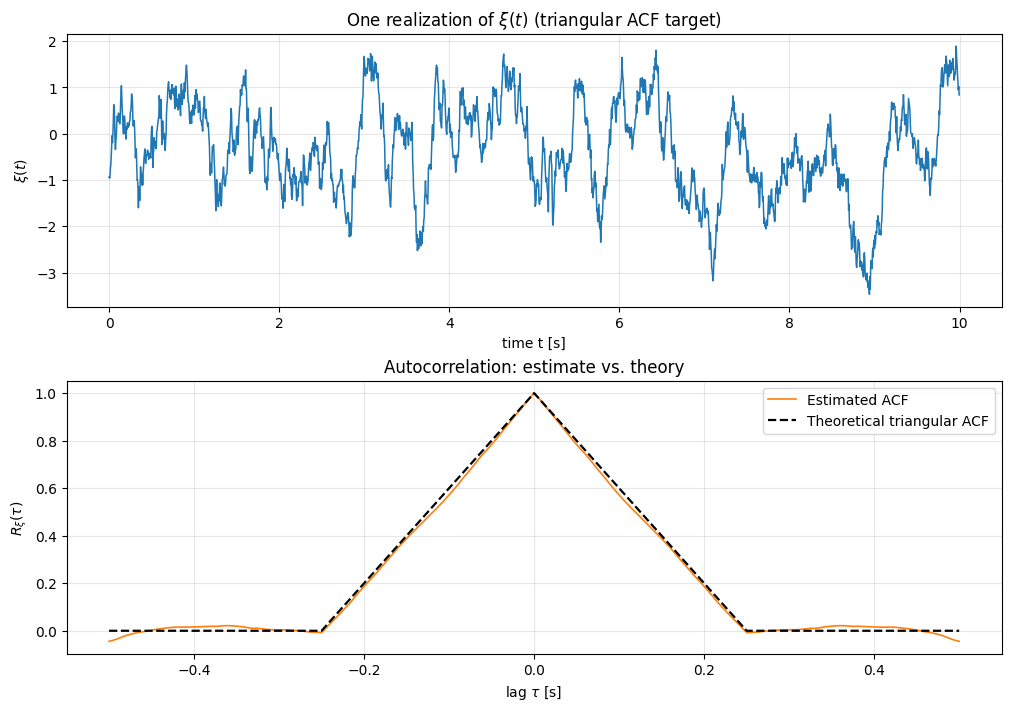

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray

def generate_xi_with_triangular_acf(
    duration_s: float,           # Total simulation time [s]
    sample_rate_hz: float,       # Sampling rate [Hz]
    sigma_xi2: float,            # Target variance R_xi(0)
    corr_span_s: float,          # Correlation support T [s]
    seed: int = 7,               # Seed for reproducibility
) -> tuple[NDArray[np.float64], NDArray[np.float64], int]:
    """Generate one realization xi(t) with a triangular ACF (discrete model).

    Purpose:
        Create a WSS realization using a moving-average filter on white noise.
        The resulting discrete ACF is triangular:
        R_xi[k] = sigma_xi2 * (1 - |k|/L) for |k| < L, and 0 otherwise.

    Parameters:
        duration_s: Total duration of the generated signal [s].
        sample_rate_hz: Sampling frequency [Hz].
        sigma_xi2: Desired process variance at lag zero.
        corr_span_s: Correlation span T [s].
        seed: Seed for deterministic random generation.

    Returns:
        time_s: Time axis in seconds.
        xi: Generated process realization samples.
        corr_span_samples: Integer span L used for the triangular ACF model.

    Side effects:
        None.
    """
    if duration_s <= 0.0:
        raise ValueError("duration_s must be positive.")
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")
    if sigma_xi2 < 0.0:
        raise ValueError("sigma_xi2 must be non-negative.")
    if corr_span_s <= 0.0:
        raise ValueError("corr_span_s must be positive.")

    # Convert continuous-time settings to discrete-time model parameters.
    n_samples = int(np.round(duration_s * sample_rate_hz))
    corr_span_samples = int(np.round(corr_span_s * sample_rate_hz))
    if n_samples < 8:
        raise ValueError("duration_s and sample_rate_hz must produce at least 8 samples.")
    if corr_span_samples < 2:
        raise ValueError("corr_span_s is too small for the selected sample_rate_hz.")

    # Build an MA(L) filter and choose white-noise variance so Var[xi] = sigma_xi2.
    h = np.ones(corr_span_samples, dtype=np.float64) / corr_span_samples
    white_std = np.sqrt(sigma_xi2 * corr_span_samples)

    # Pad, filter, and crop to reduce boundary transients.
    pad_samples = 3 * corr_span_samples
    rng = np.random.default_rng(seed)
    white = rng.normal(
        loc=0.0,
        scale=white_std,
        size=n_samples + 2 * pad_samples,
    )
    xi_full = np.convolve(white, h, mode="same")
    xi = xi_full[pad_samples : pad_samples + n_samples]

    time_s = np.arange(n_samples, dtype=np.float64) / sample_rate_hz
    return time_s, xi, corr_span_samples


def estimate_unbiased_acf(
    signal: NDArray[np.float64],  # Input realization
    max_lag_samples: int,         # Maximum lag for estimation [samples]
) -> tuple[NDArray[np.int64], NDArray[np.float64]]:
    """Estimate the two-sided ACF using unbiased normalization.

    Purpose:
        Compute empirical autocorrelation over lags -K...K with denominator
        (N-|k|), so each lag is normalized by the number of overlapping samples.

    Parameters:
        signal: Input signal realization.
        max_lag_samples: Maximum lag K in samples.

    Returns:
        lags_samples: Integer lag vector from -K to K.
        acf_est: Estimated autocorrelation values for each lag.

    Side effects:
        None.
    """
    n_samples = signal.size
    if max_lag_samples < 0:
        raise ValueError("max_lag_samples must be non-negative.")
    if max_lag_samples >= n_samples:
        raise ValueError("max_lag_samples must be smaller than the signal length.")

    # Remove sample mean to estimate autocorrelation of the zero-mean component.
    centered = signal - np.mean(signal)

    # Compute full correlation and keep only the requested lag window.
    corr_full = np.correlate(centered, centered, mode="full")
    center = n_samples - 1
    lags_samples = np.arange(-max_lag_samples, max_lag_samples + 1, dtype=np.int64)
    corr_window = corr_full[center - max_lag_samples : center + max_lag_samples + 1]

    # Unbiased normalization uses the number of overlapping products at each lag.
    overlaps = n_samples - np.abs(lags_samples)
    acf_est = corr_window / overlaps
    return lags_samples, acf_est


# Example parameters
duration_s = 10.0
sample_rate_hz = 200.0
sigma_xi2 = 1.0
corr_span_s = 0.25

time_s, xi, corr_span_samples = generate_xi_with_triangular_acf(
    duration_s=duration_s,
    sample_rate_hz=sample_rate_hz,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
    seed=42,
)

max_lag_samples = int(2.0 * corr_span_samples)
lags_samples, acf_est = estimate_unbiased_acf(xi, max_lag_samples=max_lag_samples)
lags_s = lags_samples / sample_rate_hz

# Theoretical triangular ACF in discrete lags.
acf_theory = sigma_xi2 * np.maximum(1.0 - np.abs(lags_samples) / corr_span_samples, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

axes[0].plot(time_s, xi, lw=1.1, color="#1f77b4")
axes[0].set_title(r"One realization of $\xi(t)$ (triangular ACF target)")
axes[0].set_xlabel("time t [s]")
axes[0].set_ylabel(r"$\xi(t)$")
axes[0].grid(alpha=0.3)

axes[1].plot(lags_s, acf_est, lw=1.2, label="Estimated ACF", color="#ff7f0e")
axes[1].plot(lags_s, acf_theory, "k--", lw=1.6, label="Theoretical triangular ACF")
axes[1].set_title(r"Autocorrelation: estimate vs. theory")
axes[1].set_xlabel(r"lag $\tau$ [s]")
axes[1].set_ylabel(r"$R_\xi(\tau)$")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


## 5) Example: construct $x(t)$ from $\xi(t)$

Now build
$$
x(t)=\beta\,\xi(t)\cos(\omega_0 t+\Phi),
$$
with $\Phi\sim\mathcal U[-\pi,\pi]$ independent of $\xi(t)$.
The plot compares the empirical ACF of $x(t)$ against
$$
R_x(\tau)=\frac{\beta^2}{2}R_\xi(\tau)\cos(\omega_0\tau).
$$


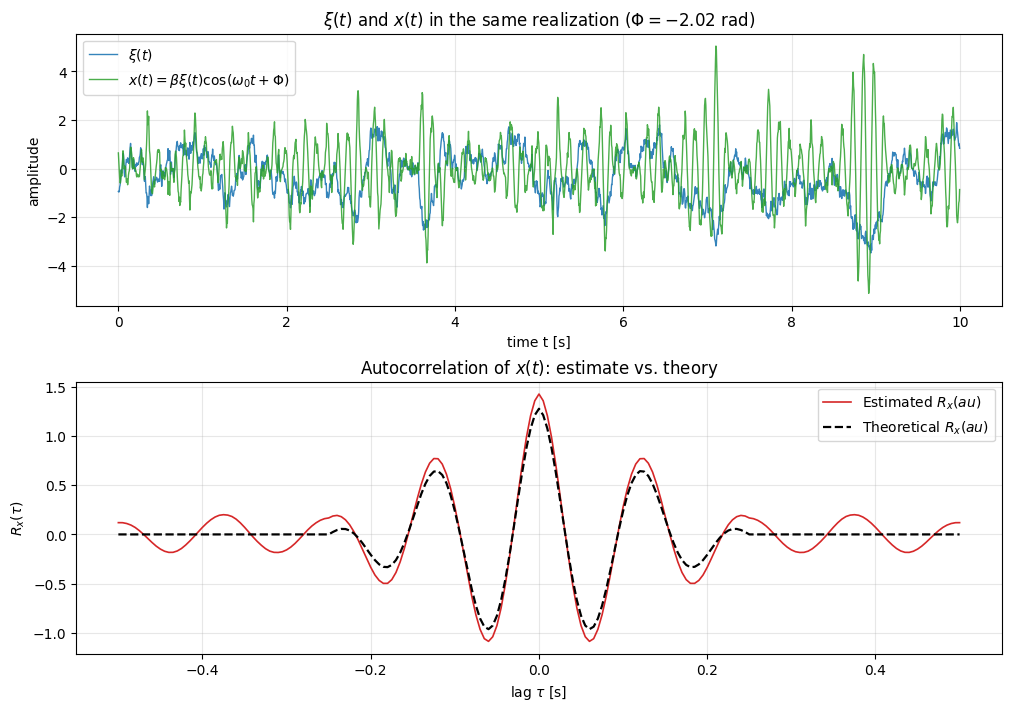

In [38]:
from typing import Tuple

def generate_x_from_xi(
    time_s: NDArray[np.float64],     # Time axis [s]
    xi: NDArray[np.float64],         # Baseband process realization
    beta: float,                     # Real amplitude scale
    omega0_rad_s: float,             # Carrier angular frequency [rad/s]
    seed_phase: int = 21,            # RNG seed for Phi
) -> Tuple[NDArray[np.float64], float]:
    """Generate x(t)=beta*xi(t)*cos(omega0*t+Phi) for one random phase.

    Purpose:
        Build a realization of the modulated process where Phi is a single
        random variable uniformly distributed in [-pi, pi], independent of xi(t).

    Parameters:
        time_s: Time samples in seconds [s].
        xi: Samples of xi(t) aligned with time_s.
        beta: Real scaling constant.
        omega0_rad_s: Angular frequency omega0 [rad/s].
        seed_phase: Seed used to sample Phi reproducibly.

    Returns:
        x: Samples of x(t).
        phi_rad: Drawn random phase Phi [rad].

    Side effects:
        None.
    """
    if time_s.ndim != 1 or xi.ndim != 1:
        raise ValueError("time_s and xi must be one-dimensional arrays.")
    if time_s.size != xi.size:
        raise ValueError("time_s and xi must have the same length.")

    # Sample the random phase once; it is constant over time for this realization.
    rng_phase = np.random.default_rng(seed_phase)
    phi_rad = float(rng_phase.uniform(-np.pi, np.pi))

    # Apply random-phase cosine modulation.
    x = beta * xi * np.cos(omega0_rad_s * time_s + phi_rad)
    return x.astype(np.float64), phi_rad


# If xi(t) is not in memory, regenerate it with the same triangular-ACF setup.
if ("xi" not in globals()) or ("time_s" not in globals()) or ("corr_span_samples" not in globals()):
    duration_s = 10.0
    sample_rate_hz = 200.0
    sigma_xi2 = 1.0
    corr_span_s = 0.25
    time_s, xi, corr_span_samples = generate_xi_with_triangular_acf(
        duration_s=duration_s,
        sample_rate_hz=sample_rate_hz,
        sigma_xi2=sigma_xi2,
        corr_span_s=corr_span_s,
        seed=42,
    )

# If sigma_xi2 is absent from globals, infer it from the realization variance.
if "sigma_xi2" not in globals():
    sigma_xi2 = float(np.var(xi))

# Recover sample rate from the time axis to keep formulas consistent.
sample_rate_hz_local = float(1.0 / np.mean(np.diff(time_s)))

# Modulation parameters for x(t).
beta = 1.6
f0_hz = 8.0
omega0_rad_s = 2.0 * np.pi * f0_hz

x, phi_rad = generate_x_from_xi(
    time_s=time_s,
    xi=xi,
    beta=beta,
    omega0_rad_s=omega0_rad_s,
    seed_phase=2026,
)

# Estimate ACF of x(t) and compare against theoretical expression.
max_lag_samples_x = int(2.0 * corr_span_samples)
lags_samples_x, acf_x_est = estimate_unbiased_acf(x, max_lag_samples=max_lag_samples_x)
lags_s_x = lags_samples_x / sample_rate_hz_local

acf_x_theory = (
    0.5
    * beta**2
    * sigma_xi2
    * np.maximum(1.0 - np.abs(lags_samples_x) / corr_span_samples, 0.0)
    * np.cos(omega0_rad_s * lags_s_x)
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

# Show baseband and modulated processes on the same axes for direct comparison.
axes[0].plot(time_s, xi, lw=1.0, color="#1f77b4", alpha=0.9, label=r"$\xi(t)$")
axes[0].plot(time_s, x, lw=1.0, color="#2ca02c", alpha=0.85, label=r"$x(t)=\beta\xi(t)\cos(\omega_0 t+\Phi)$")
axes[0].set_title(rf"$\xi(t)$ and $x(t)$ in the same realization ($\Phi={phi_rad:.2f}$ rad)")
axes[0].set_xlabel("time t [s]")
axes[0].set_ylabel("amplitude")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(lags_s_x, acf_x_est, lw=1.2, color="#d62728", label="Estimated $R_x(\tau)$")
axes[1].plot(lags_s_x, acf_x_theory, "k--", lw=1.6, label="Theoretical $R_x(\tau)$")
axes[1].set_title(r"Autocorrelation of $x(t)$: estimate vs. theory")
axes[1].set_xlabel(r"lag $\tau$ [s]")
axes[1].set_ylabel(r"$R_x(\tau)$")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


## 6) Example: rectangular pulse train with random phase

Consider a periodic rectangular pulse train with period $T_0$, duty cycle $D\in(0,1)$, and amplitude $A$.
Define
$$
x(t)=A\,q(t+\phi T_0),
$$
where $q(\cdot)$ is the unit rectangular pulse train and $\phi\sim\mathcal U[0,1)$ is independent and random.
Random phase makes the process WSS. Its autocorrelation is
$$
R_x(\tau)=\frac{A^2}{T_0}\,L_{\mathrm{ov}}(\tau),
$$
where $L_{\mathrm{ov}}(\tau)$ is the overlap length of two width-$DT_0$ intervals on a circle of length $T_0$.


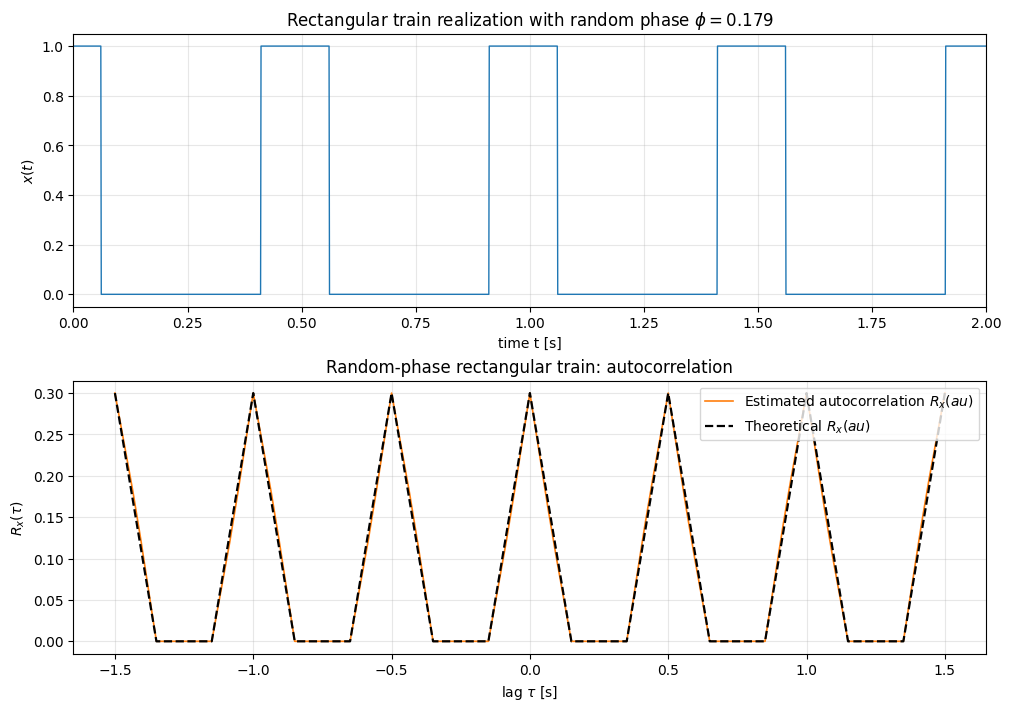

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray

def estimate_unbiased_acf(
    signal: NDArray[np.float64],  # Input realization
    max_lag_samples: int,         # Maximum lag for estimation [samples]
    mean_mode: str = "autocorrelation",  # "autocorrelation" or "covariance"
) -> tuple[NDArray[np.int64], NDArray[np.float64]]:
    """Estimate the two-sided second-order function with unbiased normalization.

    Purpose:
        Compute empirical lag statistics over lags -K...K with denominator
        (N-|k|), so each lag is normalized by overlapping sample count.
        With mean_mode="autocorrelation" it estimates E[x(t)x(t+tau)].
        With mean_mode="covariance" it estimates E[(x-m)(x_tau-m)].

    Parameters:
        signal: Input signal realization.
        max_lag_samples: Maximum lag K in samples.
        mean_mode: Statistic type, either "autocorrelation" or "covariance".

    Returns:
        lags_samples: Integer lag vector from -K to K.
        acf_est: Estimated second-order values for each lag.

    Side effects:
        None.
    """
    n_samples = signal.size
    if max_lag_samples < 0:
        raise ValueError("max_lag_samples must be non-negative.")
    if max_lag_samples >= n_samples:
        raise ValueError("max_lag_samples must be smaller than the signal length.")
    if mean_mode not in {"autocorrelation", "covariance"}:
        raise ValueError("mean_mode must be 'autocorrelation' or 'covariance'.")

    # For covariance remove mean; for autocorrelation keep the raw signal.
    proc = signal - np.mean(signal) if mean_mode == "covariance" else signal

    # Compute full correlation and keep only the requested lag window.
    corr_full = np.correlate(proc, proc, mode="full")
    center = n_samples - 1
    lags_samples = np.arange(-max_lag_samples, max_lag_samples + 1, dtype=np.int64)
    corr_window = corr_full[center - max_lag_samples : center + max_lag_samples + 1]

    # Unbiased normalization uses the number of overlapping products at each lag.
    overlaps = n_samples - np.abs(lags_samples)
    acf_est = corr_window / overlaps
    return lags_samples, acf_est


def rectangular_train_random_phase(
    time_s: NDArray[np.float64],  # Time axis [s]
    period_s: float,              # Pulse-train period T0 [s]
    duty_cycle: float,            # Duty cycle D in (0, 1)
    amplitude: float,             # Pulse amplitude A
    seed_phase: int = 123,        # RNG seed for random phase
) -> tuple[NDArray[np.float64], float]:
    """Generate one realization of a rectangular pulse train with random phase.

    Purpose:
        Build x(t) = A q(t + phi*T0), where phi ~ U[0,1).
        The random phase shift makes the process stationary in time.

    Parameters:
        time_s: Time axis in seconds [s].
        period_s: Pulse-train period T0 [s].
        duty_cycle: Fraction of each period where the pulse is ON.
        amplitude: Pulse amplitude A.
        seed_phase: Seed for reproducible random phase draw.

    Returns:
        x: Generated rectangular random-phase realization.
        phase_fraction: Drawn phase phi in [0, 1).

    Side effects:
        None.
    """
    if period_s <= 0.0:
        raise ValueError("period_s must be positive.")
    if not (0.0 < duty_cycle < 1.0):
        raise ValueError("duty_cycle must satisfy 0 < duty_cycle < 1.")

    # Sample a single random phase; it stays fixed over the whole realization.
    rng = np.random.default_rng(seed_phase)
    phase_fraction = float(rng.uniform(0.0, 1.0))

    # Convert time to phase within each period and threshold by duty cycle.
    phase_in_period = np.mod(time_s / period_s + phase_fraction, 1.0)
    x = amplitude * (phase_in_period < duty_cycle).astype(np.float64)
    return x, phase_fraction


def rectangular_train_theoretical_acf(
    tau_s: NDArray[np.float64],  # Lag values [s]
    period_s: float,             # Period T0 [s]
    duty_cycle: float,           # Duty cycle D in (0, 1)
    amplitude: float,            # Pulse amplitude A
) -> NDArray[np.float64]:
    """Evaluate theoretical autocorrelation for random-phase rectangular train.

    Purpose:
        Compute R_x(tau) = (A^2/T0) * L_ov(tau), where L_ov is the circular
        overlap of two intervals of width W = D*T0 on a circle of length T0.

    Parameters:
        tau_s: Lag values where R_x is evaluated [s].
        period_s: Pulse-train period T0 [s].
        duty_cycle: Fraction of each period in ON state.
        amplitude: Pulse amplitude A.

    Returns:
        Theoretical autocorrelation values at tau_s.

    Side effects:
        None.
    """
    width_s = duty_cycle * period_s

    # Reduce lag to one period because R_x(tau) is periodic with period T0.
    delta_s = np.mod(tau_s, period_s)

    # Circular overlap: direct overlap + wrap-around overlap contributions.
    overlap_s = np.maximum(0.0, width_s - delta_s) + np.maximum(0.0, width_s - (period_s - delta_s))
    return (amplitude**2 / period_s) * overlap_s


# Simulation setup
duration_s = 6.0
sample_rate_hz = 1000.0
period_s = 0.5
duty_cycle = 0.3
amplitude = 1.0

time_s = np.arange(int(duration_s * sample_rate_hz), dtype=np.float64) / sample_rate_hz
x_rect, phase_fraction = rectangular_train_random_phase(
    time_s=time_s,
    period_s=period_s,
    duty_cycle=duty_cycle,
    amplitude=amplitude,
    seed_phase=2026,
)

max_lag_s = 1.5
max_lag_samples = int(max_lag_s * sample_rate_hz)
lags_samples, acf_est = estimate_unbiased_acf(
    signal=x_rect,
    max_lag_samples=max_lag_samples,
    mean_mode="autocorrelation",
)
lags_s = lags_samples / sample_rate_hz
acf_theory = rectangular_train_theoretical_acf(
    tau_s=lags_s,
    period_s=period_s,
    duty_cycle=duty_cycle,
    amplitude=amplitude,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

axes[0].plot(time_s, x_rect, lw=1.0, color="#1f77b4")
axes[0].set_xlim(0.0, 2.0)
axes[0].set_title(rf"Rectangular train realization with random phase $\phi={phase_fraction:.3f}$")
axes[0].set_xlabel("time t [s]")
axes[0].set_ylabel(r"$x(t)$")
axes[0].grid(alpha=0.3)

axes[1].plot(lags_s, acf_est, lw=1.2, color="#ff7f0e", label="Estimated autocorrelation $R_x(\tau)$")
axes[1].plot(lags_s, acf_theory, "k--", lw=1.6, label="Theoretical $R_x(\tau)$")
axes[1].set_title(r"Random-phase rectangular train: autocorrelation")
axes[1].set_xlabel(r"lag $\tau$ [s]")
axes[1].set_ylabel(r"$R_x(\tau)$")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


## 7) Multiple realizations of $\xi(t)$ and $x(t)$

This figure overlays several independent realizations of $\xi(t)$ and the corresponding
modulated process $x(t)=\beta\,\xi(t)\cos(\omega_0 t+\Phi)$.

Each realization uses a different random seed for both white-noise generation and phase $\Phi$.


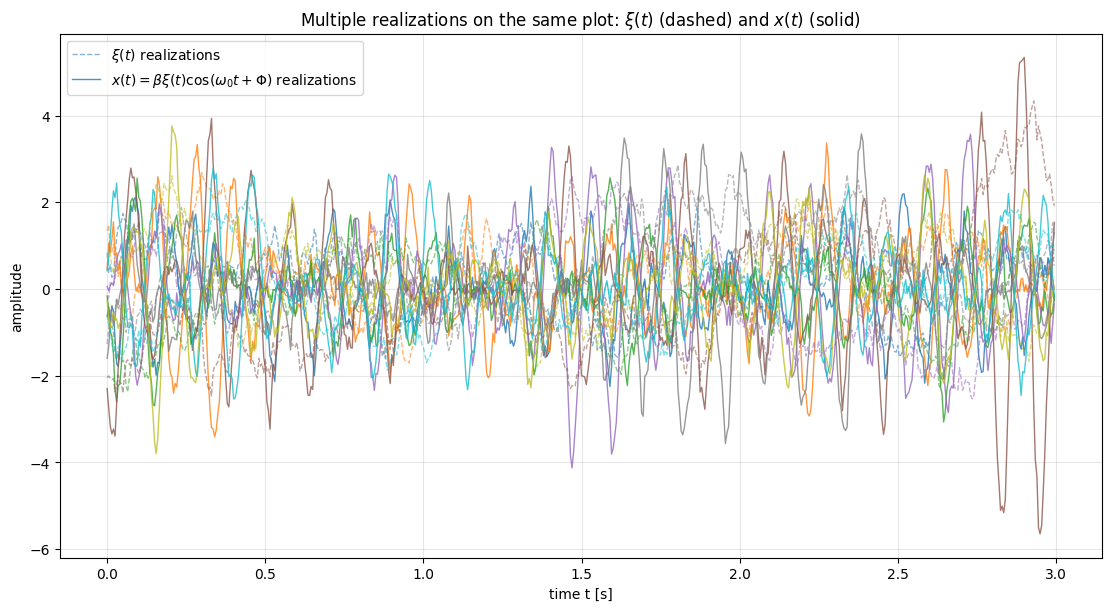

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray

def generate_multiple_realizations(
    n_realizations: int,             # Number of realizations to generate
    duration_s: float,               # Total simulation time [s]
    sample_rate_hz: float,           # Sampling rate [Hz]
    sigma_xi2: float,                # Target variance of xi(t)
    corr_span_s: float,              # Correlation span T for xi(t) [s]
    beta: float,                     # Modulation amplitude scale
    omega0_rad_s: float,             # Carrier angular frequency [rad/s]
    base_seed: int = 1000,           # Base seed for reproducible realizations
) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
    """Generate multiple paired realizations of xi(t) and x(t).

    Purpose:
        Create n independent realizations of xi(t) with triangular ACF and the
        corresponding modulated signals x(t)=beta*xi(t)*cos(omega0*t+Phi).

    Parameters:
        n_realizations: Number of independent realizations.
        duration_s: Duration of each realization [s].
        sample_rate_hz: Sampling frequency [Hz].
        sigma_xi2: Target variance for xi(t).
        corr_span_s: Triangular-ACF support T [s].
        beta: Real modulation scale factor.
        omega0_rad_s: Angular carrier frequency [rad/s].
        base_seed: Base seed used to derive deterministic per-realization seeds.

    Returns:
        time_s: Shared time axis [s].
        xi_stack: Array of shape (n_realizations, n_samples) with xi(t).
        x_stack: Array of shape (n_realizations, n_samples) with x(t).

    Side effects:
        None.
    """
    if n_realizations <= 0:
        raise ValueError("n_realizations must be a positive integer.")

    xi_list: list[NDArray[np.float64]] = []
    x_list: list[NDArray[np.float64]] = []
    time_s_ref: NDArray[np.float64] | None = None

    # Generate independent realizations by varying both xi and phase seeds.
    for idx in range(n_realizations):
        xi_seed = base_seed + idx
        phase_seed = base_seed + 10_000 + idx

        time_s, xi, _ = generate_xi_with_triangular_acf(
            duration_s=duration_s,
            sample_rate_hz=sample_rate_hz,
            sigma_xi2=sigma_xi2,
            corr_span_s=corr_span_s,
            seed=xi_seed,
        )
        x, _ = generate_x_from_xi(
            time_s=time_s,
            xi=xi,
            beta=beta,
            omega0_rad_s=omega0_rad_s,
            seed_phase=phase_seed,
        )

        if time_s_ref is None:
            time_s_ref = time_s
        xi_list.append(xi)
        x_list.append(x)

    assert time_s_ref is not None
    xi_stack = np.vstack(xi_list)
    x_stack = np.vstack(x_list)
    return time_s_ref, xi_stack, x_stack


# Configuration for multiple-realization visualization
n_realizations = 8
duration_s = 3.0
sample_rate_hz = 200.0
sigma_xi2 = 1.0
corr_span_s = 0.25
beta = 1.6
f0_hz = 8.0
omega0_rad_s = 2.0 * np.pi * f0_hz

# If prerequisite functions are missing, stop with a clear instruction.
if "generate_xi_with_triangular_acf" not in globals() or "generate_x_from_xi" not in globals():
    raise RuntimeError("Run sections 4 and 5 first to define generator functions.")

time_s, xi_stack, x_stack = generate_multiple_realizations(
    n_realizations=n_realizations,
    duration_s=duration_s,
    sample_rate_hz=sample_rate_hz,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
    beta=beta,
    omega0_rad_s=omega0_rad_s,
    base_seed=2026,
)

fig, ax = plt.subplots(1, 1, figsize=(11, 6), constrained_layout=True)

# Overlay xi(t) and x(t) on the same axes; dashed=xi(t), solid=x(t).
color_map = plt.cm.tab10(np.linspace(0.0, 1.0, min(n_realizations, 10)))
for idx in range(n_realizations):
    color = color_map[idx % color_map.shape[0]]
    ax.plot(
        time_s,
        xi_stack[idx],
        ls="--",
        lw=1.0,
        alpha=0.55,
        color=color,
        label=r"$\xi(t)$ realizations" if idx == 0 else None,
    )
    ax.plot(
        time_s,
        x_stack[idx],
        ls="-",
        lw=1.0,
        alpha=0.8,
        color=color,
        label=r"$x(t)=\beta\xi(t)\cos(\omega_0 t+\Phi)$ realizations" if idx == 0 else None,
    )

ax.set_title(r"Multiple realizations on the same plot: $\xi(t)$ (dashed) and $x(t)$ (solid)")
ax.set_xlabel("time t [s]")
ax.set_ylabel("amplitude")
ax.grid(alpha=0.3)
ax.legend()

plt.show()


## 8) Effect of different $\omega_0$ values on $x(t)$

Using a fixed realization of $\xi(t)$ and a fixed random phase $\Phi$, we vary $\omega_0$ and compare
the resulting modulated process
$$
x(t)=\beta\,\xi(t)\cos(\omega_0 t+\Phi).
$$
This isolates the effect of carrier frequency.


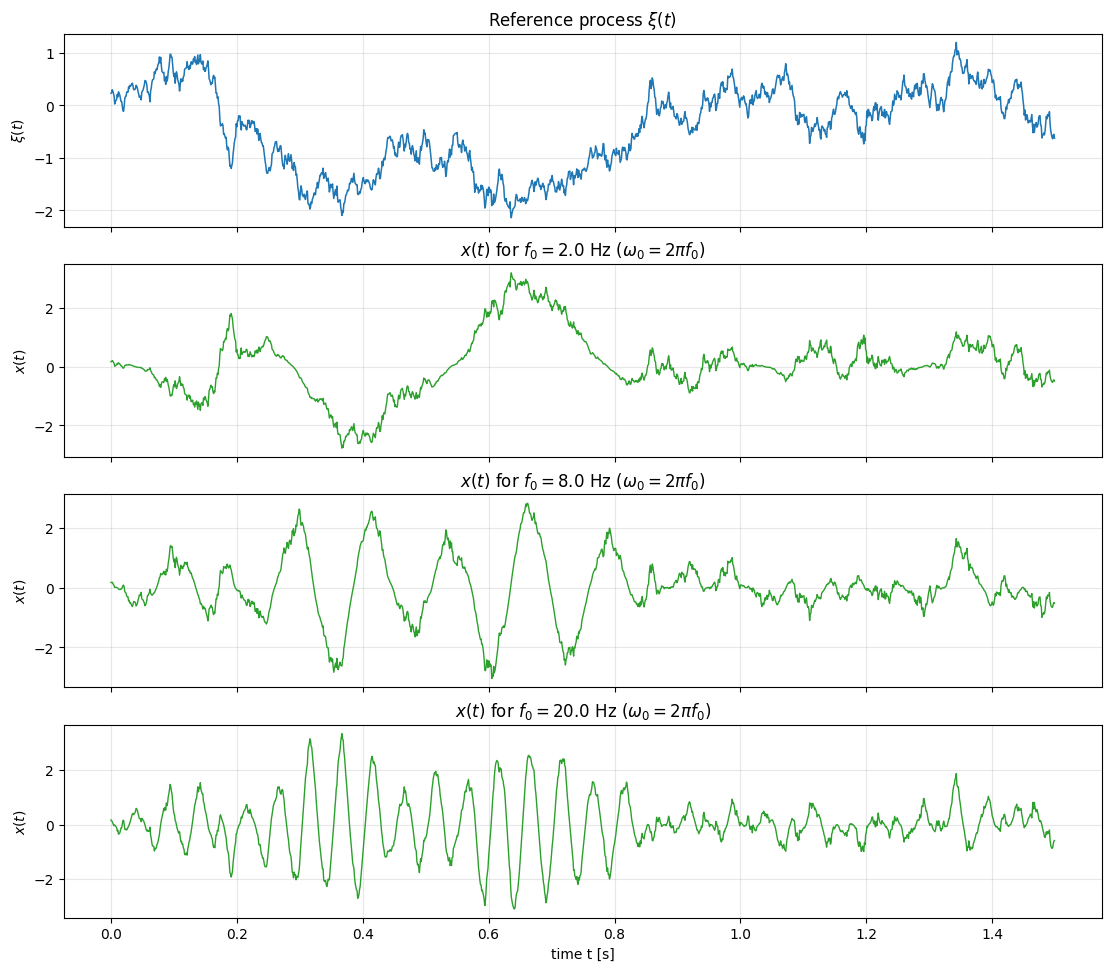

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure required generators from sections 4 and 5 are available.
if "generate_xi_with_triangular_acf" not in globals() or "generate_x_from_xi" not in globals():
    raise RuntimeError("Run sections 4 and 5 first to define generator functions.")

# Build one reference xi(t) realization shared by all omega0 cases.
duration_s = 1.5
sample_rate_hz = 1000.0
sigma_xi2 = 1.0
corr_span_s = 0.25
beta = 1.6

time_s, xi, _ = generate_xi_with_triangular_acf(
    duration_s=duration_s,
    sample_rate_hz=sample_rate_hz,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
    seed=314,
)

# Compare multiple carrier frequencies while keeping the same random phase.
f0_values_hz = np.array([2.0, 8.0, 20.0], dtype=np.float64)
omega0_values_rad_s = 2.0 * np.pi * f0_values_hz
phase_seed = 909

x_by_omega: list[np.ndarray] = []
for omega0_rad_s in omega0_values_rad_s:
    x_i, phi_rad = generate_x_from_xi(
        time_s=time_s,
        xi=xi,
        beta=beta,
        omega0_rad_s=float(omega0_rad_s),
        seed_phase=phase_seed,
    )
    x_by_omega.append(x_i)

# Plot xi(t) plus one subplot per omega0 value for direct visual comparison.
n_rows = 1 + f0_values_hz.size
fig, axes = plt.subplots(n_rows, 1, figsize=(11, 2.4 * n_rows), sharex=True, constrained_layout=True)

axes[0].plot(time_s, xi, color="#1f77b4", lw=1.1)
axes[0].set_title(r"Reference process $\xi(t)$")
axes[0].set_ylabel(r"$\xi(t)$")
axes[0].grid(alpha=0.3)

for idx, (f0_hz, x_i) in enumerate(zip(f0_values_hz, x_by_omega), start=1):
    axes[idx].plot(time_s, x_i, lw=1.0, color="#2ca02c")
    axes[idx].set_title(rf"$x(t)$ for $f_0={f0_hz:.1f}$ Hz ($\omega_0=2\pi f_0$)")
    axes[idx].set_ylabel(r"$x(t)$")
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel("time t [s]")
plt.show()


## 9) Analytical and visual verification of $R_x(\tau)$, $S_x(\omega)$, and WSS

For
$$
x(t)=\beta\,\xi(t)\cos(\omega_0 t+\Phi),
$$
with $\Phi\sim\mathcal U[-\pi,\pi]$ independent of $\xi(t)$ and $\mathbb E[\xi(t)]=0$,
$$
m_x(t)=\mathbb E[x(t)]=0.
$$
Also,
$$
R_x(\tau)=\frac{\beta^2}{2}R_\xi(\tau)\cos(\omega_0\tau).
$$
With triangular $R_\xi(\tau)=\sigma_\xi^2\left(1-\frac{|\tau|}{T}\right)_+$,
$$
R_x(\tau)=\frac{\beta^2\sigma_\xi^2}{2}\left(1-\frac{|\tau|}{T}\right)_+\cos(\omega_0\tau).
$$
By modulation in frequency,
$$
S_x(\omega)=\frac{\beta^2}{4}\left[S_\xi(\omega-\omega_0)+S_\xi(\omega+\omega_0)\right],
$$
and since
$$
S_\xi(\omega)=\sigma_\xi^2 T\,\mathrm{sinc}^2\!\left(\frac{\omega T}{2}\right)
$$
(with $\mathrm{sinc}(u)=\sin(u)/u$),
$$
S_x(\omega)=\frac{\beta^2\sigma_\xi^2 T}{4}\left[\mathrm{sinc}^2\!\left(\frac{(\omega-\omega_0)T}{2}\right)+\mathrm{sinc}^2\!\left(\frac{(\omega+\omega_0)T}{2}\right)\right].
$$
Therefore, $m_x(t)$ is constant and $R_x$ depends only on lag $\tau$: $x(t)$ is WSS.


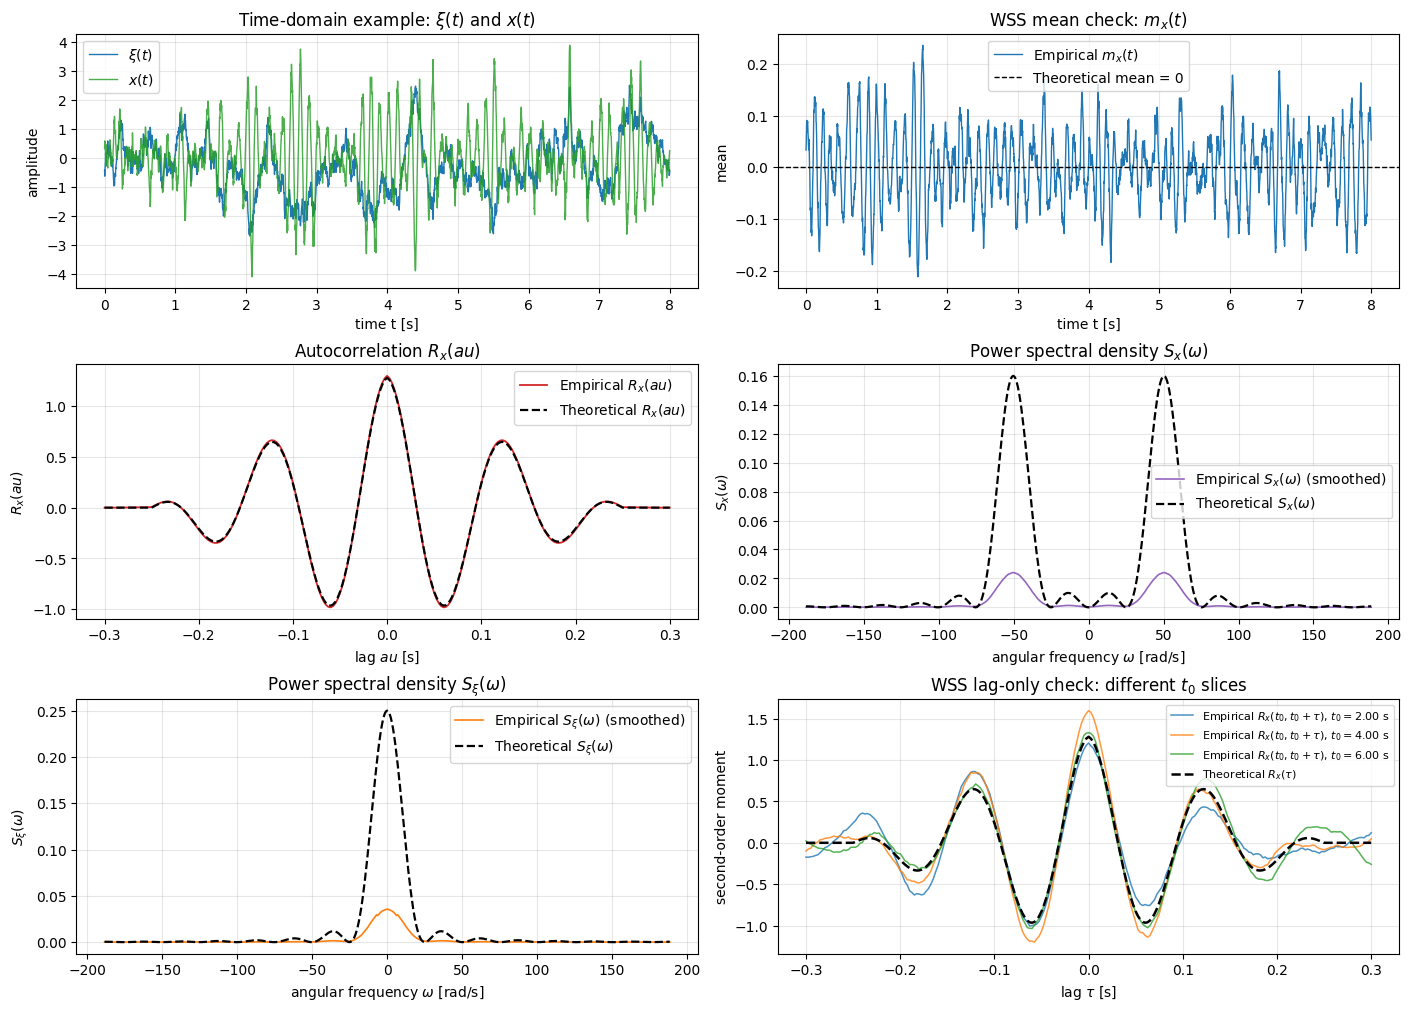

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray


def triangular_acf(
    tau_s: NDArray[np.float64],  # Lag values [s]
    sigma_xi2: float,            # Variance parameter of xi(t)
    corr_span_s: float,          # Correlation support T [s]
) -> NDArray[np.float64]:
    """Evaluate the triangular autocorrelation R_xi(tau).

    Purpose:
        Compute R_xi(tau) = sigma_xi2 * max(1 - |tau|/T, 0) for vector lags.

    Parameters:
        tau_s: Lag vector in seconds [s].
        sigma_xi2: Process variance parameter.
        corr_span_s: Correlation support T in seconds [s].

    Returns:
        Triangular ACF values evaluated at tau_s.

    Side effects:
        None.
    """
    if corr_span_s <= 0.0:
        raise ValueError("corr_span_s must be positive.")
    return sigma_xi2 * np.maximum(1.0 - np.abs(tau_s) / corr_span_s, 0.0)


def theoretical_s_xi(
    omega_rad_s: NDArray[np.float64],  # Angular frequency grid [rad/s]
    sigma_xi2: float,                  # Variance parameter of xi(t)
    corr_span_s: float,                # Correlation support T [s]
) -> NDArray[np.float64]:
    """Evaluate analytical PSD S_xi(omega) for triangular R_xi(tau).

    Purpose:
        Compute S_xi(omega)=sigma_xi2*T*sinc^2(omega*T/2), with sinc(u)=sin(u)/u.

    Parameters:
        omega_rad_s: Angular-frequency samples [rad/s].
        sigma_xi2: Variance parameter of xi(t).
        corr_span_s: Correlation support T [s].

    Returns:
        Theoretical PSD values S_xi(omega).

    Side effects:
        None.
    """
    # np.sinc(z)=sin(pi z)/(pi z). Use z=(omega*T)/(2*pi) to obtain sin(u)/u with u=omega*T/2.
    return sigma_xi2 * corr_span_s * np.sinc((omega_rad_s * corr_span_s) / (2.0 * np.pi)) ** 2


def theoretical_r_x(
    tau_s: NDArray[np.float64],  # Lag values [s]
    beta: float,                 # Modulation gain
    sigma_xi2: float,            # Variance parameter of xi(t)
    corr_span_s: float,          # Correlation support T [s]
    omega0_rad_s: float,         # Carrier angular frequency [rad/s]
) -> NDArray[np.float64]:
    """Evaluate analytical R_x(tau) for x(t)=beta*xi(t)*cos(omega0*t+Phi).

    Purpose:
        Apply R_x(tau) = (beta^2/2) * R_xi(tau) * cos(omega0*tau).

    Parameters:
        tau_s: Lag vector [s].
        beta: Modulation gain.
        sigma_xi2: Variance parameter of xi(t).
        corr_span_s: Correlation support T [s].
        omega0_rad_s: Carrier angular frequency [rad/s].

    Returns:
        Theoretical autocorrelation values R_x(tau).

    Side effects:
        None.
    """
    return 0.5 * beta**2 * triangular_acf(tau_s, sigma_xi2, corr_span_s) * np.cos(omega0_rad_s * tau_s)


def theoretical_s_x(
    omega_rad_s: NDArray[np.float64],  # Angular frequency grid [rad/s]
    beta: float,                       # Modulation gain
    sigma_xi2: float,                  # Variance parameter of xi(t)
    corr_span_s: float,                # Correlation support T [s]
    omega0_rad_s: float,               # Carrier angular frequency [rad/s]
) -> NDArray[np.float64]:
    """Evaluate analytical PSD S_x(omega) from modulation theorem.

    Purpose:
        Use S_x(omega) = (beta^2/4) * [S_xi(omega-omega0) + S_xi(omega+omega0)].

    Parameters:
        omega_rad_s: Angular-frequency samples [rad/s].
        beta: Modulation gain.
        sigma_xi2: Variance parameter of xi(t).
        corr_span_s: Correlation support T [s].
        omega0_rad_s: Carrier angular frequency [rad/s].

    Returns:
        Theoretical PSD values S_x(omega).

    Side effects:
        None.
    """
    return 0.25 * beta**2 * (
        theoretical_s_xi(omega_rad_s - omega0_rad_s, sigma_xi2, corr_span_s)
        + theoretical_s_xi(omega_rad_s + omega0_rad_s, sigma_xi2, corr_span_s)
    )


def simulate_x_ensemble(
    n_realizations: int,             # Number of independent realizations
    duration_s: float,               # Realization length [s]
    sample_rate_hz: float,           # Sampling rate [Hz]
    sigma_xi2: float,                # Variance parameter of xi(t)
    corr_span_s: float,              # Correlation support T [s]
    beta: float,                     # Modulation gain
    omega0_rad_s: float,             # Carrier angular frequency [rad/s]
    base_seed: int = 500,            # Base seed for deterministic ensemble
) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
    """Generate ensembles of xi(t) and x(t) realizations for empirical checks.

    Purpose:
        Create independent xi(t) realizations and modulate each with an
        independent random phase Phi to estimate ensemble statistics.

    Parameters:
        n_realizations: Number of realizations in the ensemble.
        duration_s: Duration per realization [s].
        sample_rate_hz: Sampling rate [Hz].
        sigma_xi2: Variance parameter of xi(t).
        corr_span_s: Correlation support T [s].
        beta: Modulation gain.
        omega0_rad_s: Carrier angular frequency [rad/s].
        base_seed: Base seed used to derive per-realization seeds.

    Returns:
        time_s: Shared time axis [s].
        xi_stack: Array with shape (n_realizations, n_samples).
        x_stack: Array with shape (n_realizations, n_samples).

    Side effects:
        None.
    """
    if n_realizations <= 0:
        raise ValueError("n_realizations must be positive.")

    xi_list: list[NDArray[np.float64]] = []
    x_list: list[NDArray[np.float64]] = []
    time_s_ref: NDArray[np.float64] | None = None

    # Build independent xi and Phi draws per realization.
    for idx in range(n_realizations):
        time_s, xi_i, _ = generate_xi_with_triangular_acf(
            duration_s=duration_s,
            sample_rate_hz=sample_rate_hz,
            sigma_xi2=sigma_xi2,
            corr_span_s=corr_span_s,
            seed=base_seed + idx,
        )
        x_i, _ = generate_x_from_xi(
            time_s=time_s,
            xi=xi_i,
            beta=beta,
            omega0_rad_s=omega0_rad_s,
            seed_phase=base_seed + 10_000 + idx,
        )

        if time_s_ref is None:
            time_s_ref = time_s
        xi_list.append(xi_i)
        x_list.append(x_i)

    assert time_s_ref is not None
    return time_s_ref, np.vstack(xi_list), np.vstack(x_list)


def ensemble_acf(
    x_stack: NDArray[np.float64],  # Ensemble matrix (n_realizations, n_samples)
    max_lag_samples: int,          # Max lag K [samples]
) -> tuple[NDArray[np.int64], NDArray[np.float64]]:
    """Estimate R_x(tau) by averaging products over realizations and time.

    Purpose:
        Compute lag-domain second-order estimate using all valid sample pairs
        and all realizations, resulting in a low-variance empirical R_x(tau).

    Parameters:
        x_stack: Ensemble data matrix.
        max_lag_samples: Maximum lag K in samples.

    Returns:
        lags_samples: Integer lag vector from -K to K.
        acf_est: Estimated autocorrelation values for each lag.

    Side effects:
        None.
    """
    _, n_samples = x_stack.shape
    if max_lag_samples < 0 or max_lag_samples >= n_samples:
        raise ValueError("max_lag_samples must satisfy 0 <= K < n_samples.")

    lags_samples = np.arange(-max_lag_samples, max_lag_samples + 1, dtype=np.int64)
    acf_est = np.zeros(lags_samples.size, dtype=np.float64)

    # For each lag, average over all realizations and all valid time indices.
    for idx, lag in enumerate(lags_samples):
        if lag >= 0:
            products = x_stack[:, : n_samples - lag] * x_stack[:, lag:]
        else:
            lag_abs = -lag
            products = x_stack[:, lag_abs:] * x_stack[:, : n_samples - lag_abs]
        acf_est[idx] = np.mean(products)

    return lags_samples, acf_est


def average_periodogram(
    x_stack: NDArray[np.float64],  # Ensemble matrix (n_realizations, n_samples)
    sample_rate_hz: float,         # Sampling rate [Hz]
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """Compute average two-sided periodogram as empirical PSD estimate.

    Purpose:
        Estimate PSD by averaging per-realization periodograms and return
        an fftshifted representation in angular-frequency units [rad/s].

    Parameters:
        x_stack: Ensemble data matrix.
        sample_rate_hz: Sampling rate [Hz].

    Returns:
        omega_rad_s: Angular-frequency axis [rad/s].
        psd_est_omega: Average periodogram estimate per rad/s.

    Side effects:
        None.
    """
    _, n_samples = x_stack.shape

    # Remove sample mean per realization to reduce residual DC estimation bias.
    centered = x_stack - np.mean(x_stack, axis=1, keepdims=True)

    # Periodogram in Hz units, then convert density to per-rad/s via S_omega = S_f / (2*pi).
    spectrum = np.fft.fft(centered, axis=1)
    psd_hz = np.mean(np.abs(spectrum) ** 2, axis=0) / (sample_rate_hz * n_samples)
    freq_hz = np.fft.fftfreq(n_samples, d=1.0 / sample_rate_hz)

    omega_rad_s = 2.0 * np.pi * np.fft.fftshift(freq_hz)
    psd_est_omega = np.fft.fftshift(psd_hz) / (2.0 * np.pi)
    return omega_rad_s.astype(np.float64), psd_est_omega.astype(np.float64)


def correlation_slices_by_time(
    x_stack: NDArray[np.float64],   # Ensemble matrix (n_realizations, n_samples)
    tau_samples: NDArray[np.int64], # Lag vector [samples]
    ref_indices: NDArray[np.int64], # Reference time indices t0 [samples]
) -> dict[int, NDArray[np.float64]]:
    """Estimate R_x(t0, t0+tau) slices for multiple reference times.

    Purpose:
        Provide a direct visual WSS check: if process is WSS, these slices
        should collapse onto a single curve versus tau.

    Parameters:
        x_stack: Ensemble data matrix.
        tau_samples: Integer lag vector [samples].
        ref_indices: Reference indices where slices are evaluated.

    Returns:
        Dictionary mapping t0 index to estimated correlation slice values.

    Side effects:
        None.
    """
    _, n_samples = x_stack.shape
    slices: dict[int, NDArray[np.float64]] = {}

    # Evaluate E[x(t0)x(t0+tau)] for each requested reference index.
    for t0_idx in ref_indices:
        values = np.full(tau_samples.size, np.nan, dtype=np.float64)
        valid = (t0_idx + tau_samples >= 0) & (t0_idx + tau_samples < n_samples)
        lag_indices = t0_idx + tau_samples[valid]
        products = x_stack[:, [t0_idx]] * x_stack[:, lag_indices]
        values[valid] = np.mean(products, axis=0)
        slices[int(t0_idx)] = values

    return slices


# Ensure prerequisite generator functions exist from sections 4 and 5.
if "generate_xi_with_triangular_acf" not in globals() or "generate_x_from_xi" not in globals():
    raise RuntimeError("Run sections 4 and 5 first to define generator functions.")

# Simulation parameters for analytical-vs-empirical validation.
n_realizations = 250
duration_s = 8.0
sample_rate_hz = 400.0
sigma_xi2 = 1.0
corr_span_s = 0.25
beta = 1.6
f0_hz = 8.0
omega0_rad_s = 2.0 * np.pi * f0_hz

time_s, xi_stack, x_stack = simulate_x_ensemble(
    n_realizations=n_realizations,
    duration_s=duration_s,
    sample_rate_hz=sample_rate_hz,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
    beta=beta,
    omega0_rad_s=omega0_rad_s,
    base_seed=2026,
)

# 1) Empirical ensemble mean vs time for WSS mean check.
mean_empirical = np.mean(x_stack, axis=0)

# 2) Empirical and theoretical autocorrelation R_x(tau).
max_lag_samples = int(1.2 * corr_span_s * sample_rate_hz)
lags_samples, r_x_emp = ensemble_acf(x_stack, max_lag_samples=max_lag_samples)
tau_s = lags_samples / sample_rate_hz
r_x_theory = theoretical_r_x(
    tau_s=tau_s,
    beta=beta,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
    omega0_rad_s=omega0_rad_s,
)

# 3) Empirical and theoretical PSDs S_x(omega) and S_xi(omega).
omega_x_rad_s, s_x_emp = average_periodogram(x_stack, sample_rate_hz=sample_rate_hz)
omega_xi_rad_s, s_xi_emp = average_periodogram(xi_stack, sample_rate_hz=sample_rate_hz)
if not np.allclose(omega_x_rad_s, omega_xi_rad_s):
    raise RuntimeError("Frequency grids for x and xi PSD estimates do not match.")

s_x_theory = theoretical_s_x(
    omega_rad_s=omega_x_rad_s,
    beta=beta,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
    omega0_rad_s=omega0_rad_s,
)
s_xi_theory = theoretical_s_xi(
    omega_rad_s=omega_xi_rad_s,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
)

# Smooth empirical PSDs for readability without changing broad spectral trends.
window_len = 17
smoothing_kernel = np.ones(window_len, dtype=np.float64) / window_len
s_x_emp_smooth = np.convolve(s_x_emp, smoothing_kernel, mode="same")
s_xi_emp_smooth = np.convolve(s_xi_emp, smoothing_kernel, mode="same")

# 4) WSS slice check: R_x(t0, t0+tau) for different t0 values should overlap.
tau_samples_slice = np.arange(-max_lag_samples, max_lag_samples + 1, dtype=np.int64)
ref_indices = np.array(
    [
        int(0.25 * time_s.size),
        int(0.50 * time_s.size),
        int(0.75 * time_s.size),
    ],
    dtype=np.int64,
)
slice_dict = correlation_slices_by_time(x_stack, tau_samples=tau_samples_slice, ref_indices=ref_indices)
tau_slice_s = tau_samples_slice / sample_rate_hz
r_x_theory_slice = theoretical_r_x(
    tau_s=tau_slice_s,
    beta=beta,
    sigma_xi2=sigma_xi2,
    corr_span_s=corr_span_s,
    omega0_rad_s=omega0_rad_s,
)

# Representative realization for time-domain visualization.
xi_example = xi_stack[0]
x_example = x_stack[0]

# Assemble a 3x2 diagnostic figure including time-domain and both PSDs.
fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)

axes[0, 0].plot(time_s, xi_example, lw=1.0, color="#1f77b4", label=r"$\xi(t)$")
axes[0, 0].plot(time_s, x_example, lw=1.0, color="#2ca02c", alpha=0.85, label=r"$x(t)$")
axes[0, 0].set_title(r"Time-domain example: $\xi(t)$ and $x(t)$")
axes[0, 0].set_xlabel("time t [s]")
axes[0, 0].set_ylabel("amplitude")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(time_s, mean_empirical, color="#1f77b4", lw=1.0, label=r"Empirical $m_x(t)$")
axes[0, 1].axhline(0.0, color="k", ls="--", lw=1.0, label="Theoretical mean = 0")
axes[0, 1].set_title(r"WSS mean check: $m_x(t)$")
axes[0, 1].set_xlabel("time t [s]")
axes[0, 1].set_ylabel("mean")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(tau_s, r_x_emp, color="#d62728", lw=1.3, label=r"Empirical $R_x(	au)$")
axes[1, 0].plot(tau_s, r_x_theory, "k--", lw=1.6, label=r"Theoretical $R_x(	au)$")
axes[1, 0].set_title(r"Autocorrelation $R_x(	au)$")
axes[1, 0].set_xlabel(r"lag $	au$ [s]")
axes[1, 0].set_ylabel(r"$R_x(	au)$")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

omega_limit_rad_s = 2.0 * np.pi * 30.0
mask_band = np.abs(omega_x_rad_s) <= omega_limit_rad_s
axes[1, 1].plot(
    omega_x_rad_s[mask_band],
    s_x_emp_smooth[mask_band],
    color="#9467bd",
    lw=1.2,
    label=r"Empirical $S_x(\omega)$ (smoothed)",
)
axes[1, 1].plot(
    omega_x_rad_s[mask_band],
    s_x_theory[mask_band],
    "k--",
    lw=1.6,
    label=r"Theoretical $S_x(\omega)$",
)
axes[1, 1].set_title(r"Power spectral density $S_x(\omega)$")
axes[1, 1].set_xlabel(r"angular frequency $\omega$ [rad/s]")
axes[1, 1].set_ylabel(r"$S_x(\omega)$")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

axes[2, 0].plot(
    omega_xi_rad_s[mask_band],
    s_xi_emp_smooth[mask_band],
    color="#ff7f0e",
    lw=1.2,
    label=r"Empirical $S_\xi(\omega)$ (smoothed)",
)
axes[2, 0].plot(
    omega_xi_rad_s[mask_band],
    s_xi_theory[mask_band],
    "k--",
    lw=1.6,
    label=r"Theoretical $S_\xi(\omega)$",
)
axes[2, 0].set_title(r"Power spectral density $S_\xi(\omega)$")
axes[2, 0].set_xlabel(r"angular frequency $\omega$ [rad/s]")
axes[2, 0].set_ylabel(r"$S_\xi(\omega)$")
axes[2, 0].grid(alpha=0.3)
axes[2, 0].legend()

for t0_idx, values in slice_dict.items():
    label = rf"Empirical $R_x(t_0, t_0+\tau)$, $t_0={time_s[t0_idx]:.2f}$ s"
    axes[2, 1].plot(tau_slice_s, values, lw=1.1, alpha=0.8, label=label)
axes[2, 1].plot(tau_slice_s, r_x_theory_slice, "k--", lw=1.8, label=r"Theoretical $R_x(\tau)$")
axes[2, 1].set_title(r"WSS lag-only check: different $t_0$ slices")
axes[2, 1].set_xlabel(r"lag $\tau$ [s]")
axes[2, 1].set_ylabel(r"second-order moment")
axes[2, 1].grid(alpha=0.3)
axes[2, 1].legend(fontsize=8)

plt.show()
